# Exploratory Data Analysis

Chicago Traffic Crash Analytics, Checkpoint 3

Research question: What factors predict whether a Chicago traffic crash
results in injury, and do time-of-day and weather effects persist after
controlling for road and crash characteristics?

This notebook loads the full 2023-2024 pull (see
`scripts/fetch_full_data.py`, data cached in `data/raw/*.parquet`), profiles
the two primary datasets, documents anomalies, and plots distributions and
relationships relevant to the research question.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (8, 5)

crashes = pd.read_parquet("../data/raw/crashes.parquet")
people = pd.read_parquet("../data/raw/people.parquet")


## 1. Dataset Profiles

### Traffic Crashes - Crashes


In [2]:
crashes.shape

(222811, 49)

In [3]:
crashes.dtypes

crash_record_id                     str
crash_date                          str
posted_speed_limit                  str
traffic_control_device              str
device_condition                    str
weather_condition                   str
lighting_condition                  str
first_crash_type                    str
trafficway_type                     str
alignment                           str
roadway_surface_cond                str
road_defect                         str
report_type                         str
crash_type                          str
damage                              str
date_police_notified                str
prim_contributory_cause             str
sec_contributory_cause              str
street_no                           str
street_direction                    str
street_name                         str
beat_of_occurrence                  str
num_units                           str
crash_month                         str
most_severe_injury                  str


In [4]:
crashes.isnull().sum().sort_values(ascending=False)

lane_cnt                         222786
workers_present_i                222553
work_zone_type                   222070
dooring_i                        222069
work_zone_i                      221782
photos_taken_i                   218855
statements_taken_i               216143
private_property_i               213621
crash_date_est_i                 207743
intersection_related_i           171109
hit_and_run_i                    150435
report_type                        9717
location                           2222
longitude                          2222
latitude                           2222
idot_control_no                    1192
most_severe_injury                  512
injuries_fatal                      509
injuries_incapacitating             509
injuries_unknown                    509
injuries_no_indication              509
injuries_reported_not_evident       509
injuries_total                      509
injuries_non_incapacitating         509
roadway_surface_cond                  0


In [5]:
relevant_cols = [
    "posted_speed_limit", "weather_condition", "lighting_condition",
    "roadway_surface_cond", "road_defect", "first_crash_type",
    "crash_hour", "crash_day_of_week", "most_severe_injury", "injuries_total",
]
crashes[relevant_cols].describe(include="all").T


,count,unique,top,freq
posted_speed_limit,222811,34,30,165282
weather_condition,222811,12,CLEAR,171691
lighting_condition,222811,6,DAYLIGHT,139854
roadway_surface_cond,222811,7,DRY,160566
road_defect,222811,7,NO DEFECTS,162257
first_crash_type,222811,18,PARKED MOTOR VEHICLE,50272
crash_hour,222811,24,15,17789
crash_day_of_week,222811,7,6,35478
most_severe_injury,222299,5,NO INDICATION OF INJURY,187089
injuries_total,222302,25,0,185117


**What stands out:** Every column from the Socrata API comes back as `str`,
even clearly numeric ones (`posted_speed_limit`, `injuries_total`,
`crash_hour`), these need `pd.to_numeric()` before any real analysis.
`lane_cnt`, `workers_present_i`, `work_zone_type`, `dooring_i`, `work_zone_i`
are >99% null (these are rare-event flag columns, mostly N/A rather than
missing data). Core crash fields (`weather_condition`, `lighting_condition`,
`roadway_surface_cond`, etc.) have **zero** nulls, but that's because
Socrata encodes "don't know" as the string `"UNKNOWN"` rather than a null, so
null-counting alone understates missingness for these columns (see Anomalies
below). `most_severe_injury`/`injuries_total` are missing in 509-512 rows ,
small enough to drop for modeling without much loss.


### Traffic Crashes - People

In [6]:
people.shape

(491892, 29)

In [7]:
people.dtypes

person_id                str
person_type              str
crash_record_id          str
vehicle_id               str
crash_date               str
sex                      str
safety_equipment         str
airbag_deployed          str
ejection                 str
injury_classification    str
driver_action            str
driver_vision            str
physical_condition       str
bac_result               str
city                     str
state                    str
zipcode                  str
age                      str
drivers_license_state    str
drivers_license_class    str
hospital                 str
ems_agency               str
pedpedal_action          str
pedpedal_visibility      str
pedpedal_location        str
bac_result_value         str
cell_phone_use           str
seat_no                  str
ems_run_no               str
dtype: object

In [8]:
people.isnull().sum().sort_values(ascending=False)

cell_phone_use           491890
bac_result_value         491499
ems_run_no               484948
pedpedal_visibility      480845
pedpedal_action          480831
pedpedal_location        480827
ems_agency               451838
hospital                 426860
seat_no                  392790
drivers_license_class    269069
drivers_license_state    207651
zipcode                  159183
age                      143700
city                     137935
state                    130314
driver_vision            100144
bac_result               100033
driver_action             99954
physical_condition        99702
vehicle_id                11315
airbag_deployed           10944
sex                       10208
ejection                   6779
safety_equipment           1295
injury_classification       101
person_type                   0
crash_date                    0
crash_record_id               0
person_id                     0
dtype: int64

In [9]:
people_relevant_cols = [
    "person_type", "sex", "age", "safety_equipment",
    "airbag_deployed", "injury_classification", "driver_action",
]
people[people_relevant_cols].describe(include="all").T


,count,unique,top,freq
person_type,491892,6,DRIVER,381515
sex,481684,3,M,252690
age,348192,110,26,9475
safety_equipment,490597,18,USAGE UNKNOWN,263904
airbag_deployed,480948,7,DID NOT DEPLOY,183608
injury_classification,491791,5,NO INDICATION OF INJURY,442266
driver_action,391938,20,NONE,133624


**What stands out:** 491,892 person-level rows for 222,811 crashes, about
2.2 people per crash on average, as expected. `age` is missing for ~29% of
rows and `sex` for ~2%; several EMS/pedestrian/BAC columns are >80-99% null
because they only apply to specific person types (e.g. `pedpedal_*` columns
only apply to pedestrians/cyclists, a small share of all people). Most
common `injury_classification` is "NO INDICATION OF INJURY" (442,266 of
491,791 non-null, ~90%), injury is a rare-ish outcome at the person level,
same pattern as the crash-level `most_severe_injury` field.


## 2. Anomalies

_(Work through this section systematically: duplicates, missing values,
inconsistent formatting, wrong dtypes, invalid values, mixed units. For each
one found, note what it is, how many rows it affects, and what we did.)_


In [10]:
# Duplicate crash records?
crashes["crash_record_id"].duplicated().sum()


np.int64(0)

In [11]:
# Socrata returns everything as strings -- check numeric-looking columns
numeric_like = ["posted_speed_limit", "injuries_total", "injuries_fatal", "lane_cnt"]
crashes[numeric_like].apply(lambda c: pd.to_numeric(c, errors="coerce")).describe()


,posted_speed_limit,injuries_total,injuries_fatal,lane_cnt
count,222811.000000,222302.000000,222302.000000,25.00000
mean,28.588988,0.221172,0.001233,2.36000
std,5.556069,0.612063,0.037683,0.95219
min,0.000000,0.000000,0.000000,1.00000
25%,30.000000,0.000000,0.000000,2.00000
50%,30.000000,0.000000,0.000000,2.00000
75%,30.000000,0.000000,0.000000,3.00000
max,70.000000,21.000000,3.000000,4.00000


In [12]:
# How many rows have an invalid/placeholder posted speed limit (e.g. 0 or absurdly high)?
spd = pd.to_numeric(crashes["posted_speed_limit"], errors="coerce")
((spd == 0) | (spd > 70)).sum()


np.int64(364)

In [13]:
# Weather/lighting/surface "UNKNOWN" rates
for col in ["weather_condition", "lighting_condition", "roadway_surface_cond", "road_defect"]:
    print(col, (crashes[col] == "UNKNOWN").mean().round(3))


weather_condition 0.082
lighting_condition 0.067
roadway_surface_cond 0.131
road_defect 0.257


In [14]:
# People: invalid ages
age = pd.to_numeric(people["age"], errors="coerce")
((age < 0) | (age > 100)).sum(), age.isnull().sum()


(np.int64(24), np.int64(143700))

**Anomaly notes:**

| Anomaly | Rows affected | What we did |
|---|---|---|
| All columns typed as `str` by the API, including numeric fields (`posted_speed_limit`, `injuries_total`, `crash_hour`, `age`) | All 222,811 crash rows / 491,892 people rows | Cast with `pd.to_numeric(..., errors="coerce")` before any numeric analysis |
| Invalid/placeholder posted speed limit (0 mph or >70 mph) | 364 crash rows | Flagged and excluded from the speed-limit distribution plot; will exclude or cap for modeling |
| `"UNKNOWN"` used as a non-null placeholder for missing weather/lighting/surface/road-defect data | weather 8.2%, lighting 6.7%, surface 13.1%, road defect 25.7% of rows | Left in as an explicit category rather than dropped, "UNKNOWN" itself may carry signal (e.g. desk reports vs. on-scene), but we'll treat it as missing-not-at-random when modeling |
| Invalid ages (negative or >100) | 24 people rows | Will drop these rows for any age-based analysis |
| Missing age | 143,700 people rows (~29%) | Left as null; age not central to crash-level injury model, only used if we build a person-level model |
| Duplicate `crash_record_id` | 0 | Checked, none found, crash table is one-row-per-crash as expected |


## 3. Distributions

One plot per feature that matters for the research question: injury outcome,
weather, lighting, road surface, posted speed limit, crash hour.


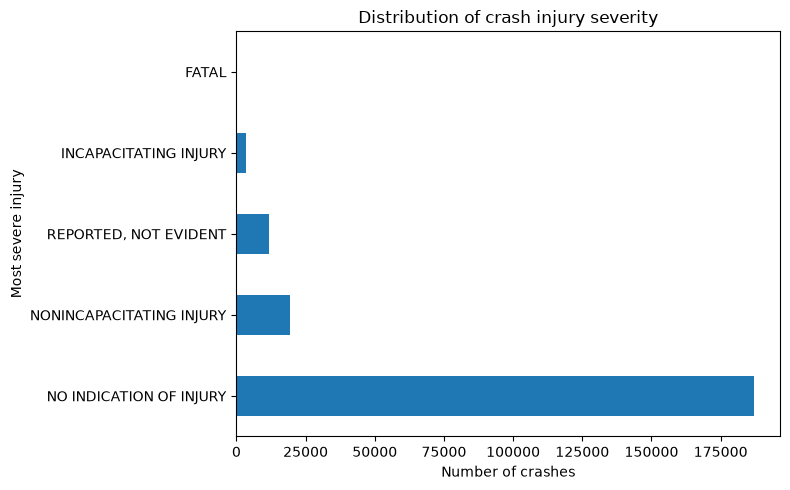

In [15]:
crashes["most_severe_injury"].value_counts().plot(kind="barh")
plt.xlabel("Number of crashes")
plt.ylabel("Most severe injury")
plt.title("Distribution of crash injury severity")
plt.tight_layout()
plt.show()


_Shape/description:_ Heavily right-skewed toward "no injury", "NO
INDICATION OF INJURY" accounts for 187,089 of 222,299 non-null crashes
(84%). The remaining 16% split across "NONINCAPACITATING INJURY",
"REPORTED, NOT EVIDENT", "INCAPACITATING INJURY", and "FATAL" (rarest).
This confirms injury is a minority-class outcome, important for modeling
(class imbalance) and matches the overall 15.8% injury rate computed below.


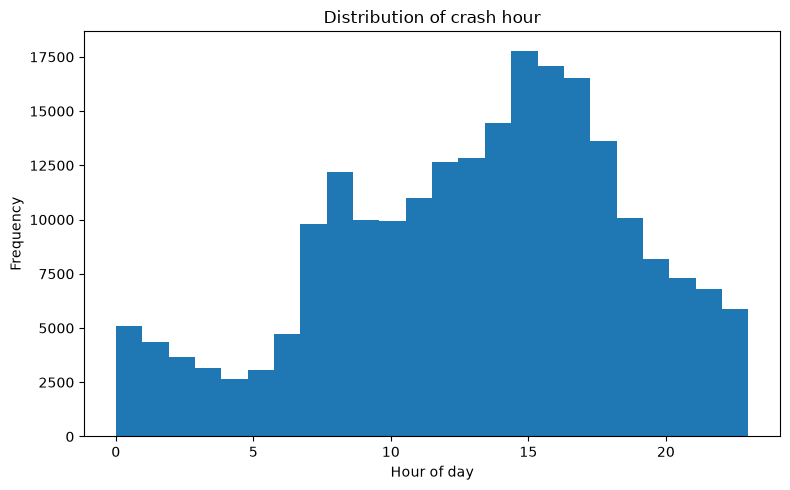

In [16]:
pd.to_numeric(crashes["crash_hour"], errors="coerce").plot(kind="hist", bins=24)
plt.xlabel("Hour of day")
plt.title("Distribution of crash hour")
plt.tight_layout()
plt.show()


_Shape/description:_ Roughly bimodal/multi-peaked rather than uniform ,
low counts overnight (roughly 1am-5am), climbing through the morning, a
midday plateau, and the largest peak in the late afternoon/early evening
(around hour 15-17, consistent with rush hour and higher general traffic
volume). No real outliers since hour is bounded 0-23 by construction.


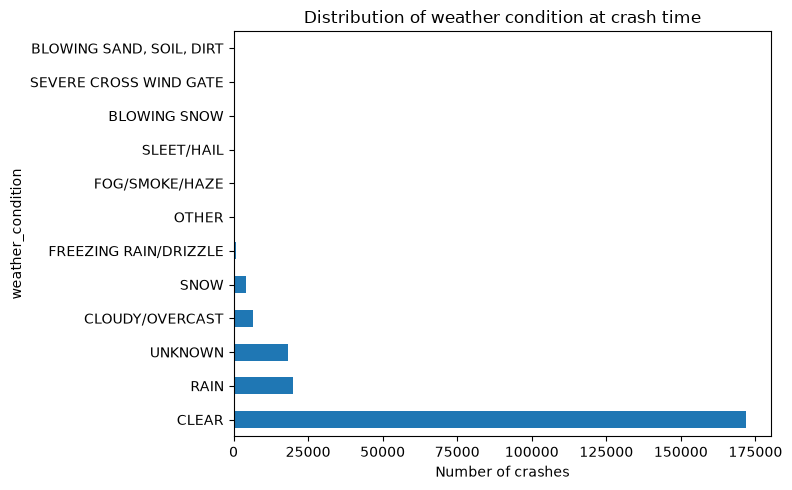

In [17]:
crashes["weather_condition"].value_counts().plot(kind="barh")
plt.xlabel("Number of crashes")
plt.title("Distribution of weather condition at crash time")
plt.tight_layout()
plt.show()


_Shape/description:_ Extremely dominated by one category, "CLEAR" accounts
for 171,691 of 222,811 crashes (77%), consistent with Chicago's actual
climate (most days are clear) and with most crashes happening in normal
conditions simply because that's when most driving happens. Long tail of
rarer conditions (RAIN, SNOW, CLOUDY/OVERCAST, etc.), each under 10%. This
class imbalance means weather-condition effects on injury will need to be
read as relative rates, not raw counts.


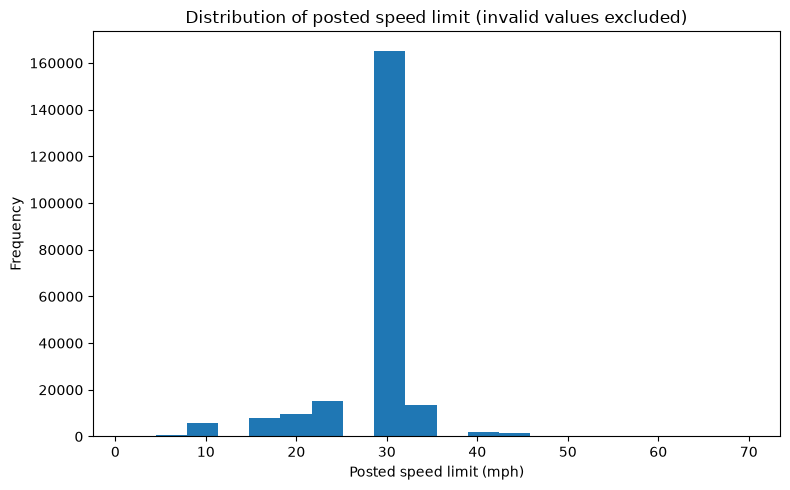

In [18]:
spd = pd.to_numeric(crashes["posted_speed_limit"], errors="coerce")
spd[(spd > 0) & (spd <= 70)].plot(kind="hist", bins=20)
plt.xlabel("Posted speed limit (mph)")
plt.title("Distribution of posted speed limit (invalid values excluded)")
plt.tight_layout()
plt.show()


_Shape/description:_ Strongly concentrated at 30 mph, the single most
common posted limit (165,282 of 222,811 rows, 74%), reflecting Chicago's
standard arterial/residential speed limit. Smaller spikes at 25, 35, and 45
mph. Center (median) is 30, with a narrow IQR (25-30) and 364 invalid rows
(0 mph or >70 mph) excluded from this plot as placeholder/bad values rather
than real speed limits.


## 4. Relationships

At least 3 plots relating two+ features, chosen with the research question
in mind.


### Relationship 1: Injury rate by hour of day

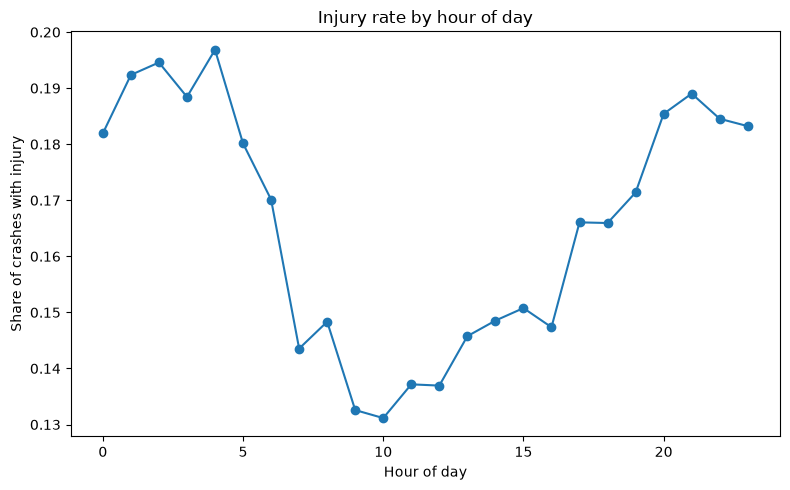

In [19]:
crashes["injured"] = crashes["injuries_total"].astype(float).fillna(0) > 0
crashes["crash_hour_num"] = pd.to_numeric(crashes["crash_hour"], errors="coerce")
by_hour = crashes.groupby("crash_hour_num")["injured"].mean()
by_hour.plot(kind="line", marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Share of crashes with injury")
plt.title("Injury rate by hour of day")
plt.tight_layout()
plt.show()


**So what?** Injury rate is not flat across the day, it's lowest midday
(~13% around 10am-1pm) and highest overnight/late evening (~19-20% around
midnight-4am and 9-11pm), against an overall average of 15.8%. This is a
~6-7 percentage point swing, meaningful relative to the base rate. This was
partly expected (less traffic overnight can mean higher speeds and worse
outcomes per crash, even though there are fewer crashes overall) but the
sharpness of the overnight peak was a bit more pronounced than anticipated.

**What next?** Worth checking whether this overnight pattern is actually a
lighting-condition effect in disguise (darkness vs. streetlights) or a
separate time-of-day effect, that's part of why we also plot lighting and
the lighting x weather interaction next. For modeling, `crash_hour` as a
control/predictor should probably be binned (e.g. day/evening/overnight)
rather than used as a raw linear hour given the non-monotonic shape.


### Relationship 2: Injury rate by weather condition

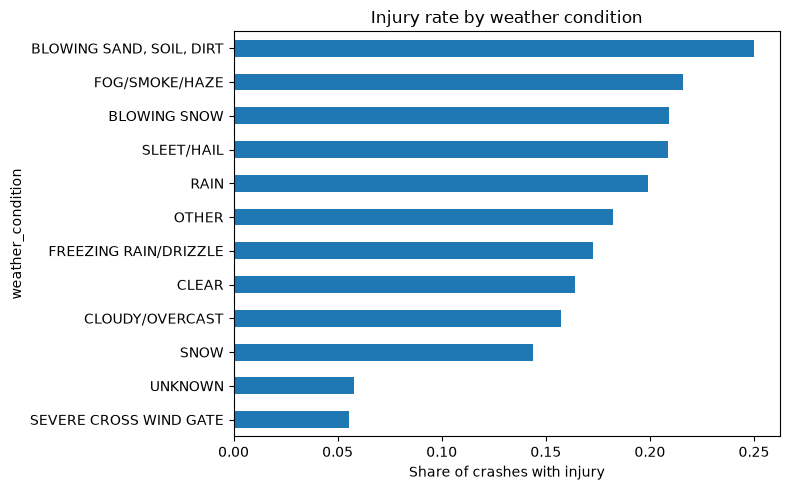

In [20]:
by_weather = crashes.groupby("weather_condition")["injured"].mean().sort_values()
by_weather.plot(kind="barh")
plt.xlabel("Share of crashes with injury")
plt.title("Injury rate by weather condition")
plt.tight_layout()
plt.show()


**So what?** Severe/rare weather conditions have higher injury rates:
"BLOWING SAND, SOIL, DIRT" (25.0%), "FOG/SMOKE/HAZE" (21.6%), "BLOWING
SNOW"/"SLEET/HAIL" (~20.9%), and "RAIN" (19.9%) all sit well above the
15.8% overall average and above "CLEAR" (16.4%). Interestingly "SNOW" alone
is actually below average (14.4%), likely because drivers slow down more
in visible snow than in rain or low-visibility conditions, or because snow
routes/plowing reduce severity. "UNKNOWN" and "SEVERE CROSS WIND GATE" have
the lowest rates (~5-6%), but those are very likely driven by small/noisy
samples or reporting artifacts rather than a real protective effect, worth
checking row counts before reading into that.

**What next?** This roughly matches domain expectation that reduced
visibility/traction conditions raise injury severity, but the SNOW
exception is a genuine surprise worth digging into, split by road surface
condition (wet/snow/ice) and by posted speed to see if drivers compensate.
Also worth checking whether rare categories like "BLOWING SAND" have enough
observations to trust the rate at all before using this feature in a model.


### Relationship 3: Injury rate by lighting condition x weather (subgroup comparison)

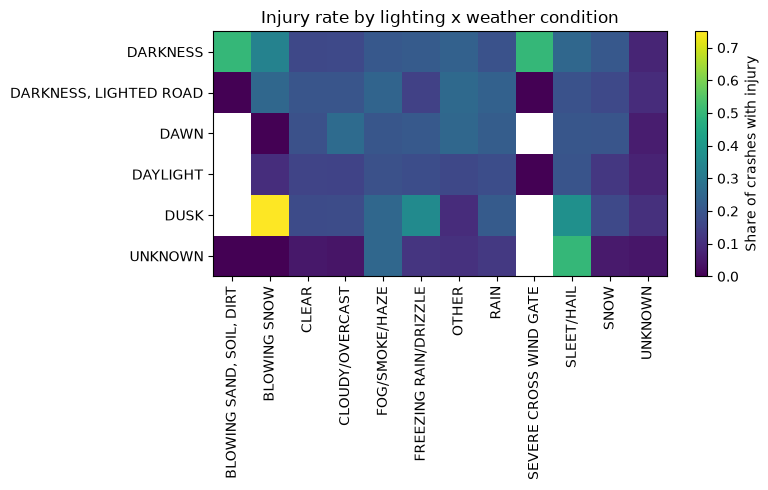

In [21]:
pivot = crashes.pivot_table(
    index="lighting_condition", columns="weather_condition",
    values="injured", aggfunc="mean"
)
plt.imshow(pivot, aspect="auto", cmap="viridis")
plt.colorbar(label="Share of crashes with injury")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Injury rate by lighting x weather condition")
plt.tight_layout()
plt.show()


**So what?** Lighting alone shows the same overnight pattern as crash hour:
"DARKNESS, LIGHTED ROAD" (19.8%) and "DAWN" (19.3%) have the highest injury
rates, "DAYLIGHT" the lowest (15.4%), with plain "DARKNESS" (unlit, 16.2%)
landing in between, slightly surprising that lit darkness has a *higher*
rate than unlit darkness, which may mean lit darkness roads are busier
arterials with higher speeds rather than lighting itself being causal. The
heatmap shows the darkness/weather combinations (e.g. rain at night) tend to
stack toward the highest injury rates in the grid, suggesting some
interaction rather than two fully independent effects.

**What next?** This is the key motivating evidence for the research
question's "controlling for" framing, time-of-day and lighting look
correlated with each other and with weather, so a model needs to include
all three together (plus road surface/defect) to see whether each effect
survives independently or whether one is just a proxy for another. Next
step is the regression stage: baseline model with just hour+weather, then a
full model adding lighting/road surface/speed limit/crash type, and compare
coefficients.


### Relationship 4: Arterial congestion speed vs. crash injury rate, by hour (secondary dataset)

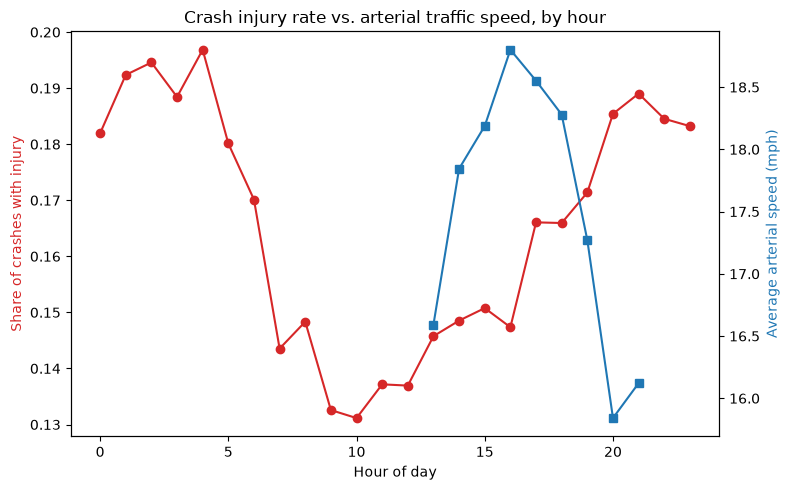

In [22]:
congestion = pd.read_parquet("../data/raw/congestion.parquet")
congestion["speed_num"] = pd.to_numeric(congestion["speed"], errors="coerce")
congestion["hour_num"] = pd.to_numeric(congestion["hour"], errors="coerce")
speed_by_hour = congestion.groupby("hour_num")["speed_num"].mean()

fig, ax1 = plt.subplots()
ax1.plot(by_hour.index, by_hour.values, color="tab:red", marker="o", label="Injury rate")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Share of crashes with injury", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(speed_by_hour.index, speed_by_hour.values, color="tab:blue", marker="s", label="Avg arterial speed (mph)")
ax2.set_ylabel("Average arterial speed (mph)", color="tab:blue")
plt.title("Crash injury rate vs. arterial traffic speed, by hour")
fig.tight_layout()
plt.show()


**So what?** This join uses the Traffic Tracker Congestion dataset
described in Checkpoint 2, average arterial speed by hour compared against
crash injury rate by hour (different time periods: one day of congestion
data vs. the full 2023-2024 crash window, since congestion is a live feed
and crashes are historical). Caveat: this single-day pull only has readings
for hours 13-21, not the full 24 hours, so this is a partial look, not a
full-day comparison. Within that window, average speed rises through the
afternoon (16.6 mph at 1pm to a peak of 18.8 mph at 4pm) then declines into
the evening (15.8 mph at 8pm), and crash injury rate moves in the
*opposite* direction over roughly the same hours (lower around midday,
climbing into the evening). This is consistent with the idea that higher
speeds on less-congested arterials are associated with more severe crash
outcomes when a crash does happen, though this is only descriptive, not
causal, and the two datasets aren't from the same days.

**What next?** Pull congestion data for a full day (or several, matched to
the same months as a crash subsample) to confirm the pattern holds across
the full 24-hour cycle, not just hours 13-21. If it holds, average segment
speed (as a proxy for traffic volume/congestion) would be worth adding as a
control alongside weather and lighting in the injury model, since it may
explain part of the time-of-day effect on injury severity.


## 5. Research questions, revisited

Original: What factors predict whether a Chicago traffic crash results in
injury, and do time-of-day and weather effects persist after controlling
for road and crash characteristics?

The EDA mostly confirms this question is answerable with the data we have,
with a couple of refinements:

- **Injury is a minority outcome (~16%)**, so the eventual model needs to
  account for class imbalance (e.g. class weights, or report
  precision/recall rather than accuracy alone), this wasn't explicit in
  the original question but is now a required part of "predict."
- **Time-of-day, lighting, and weather look correlated with each other**
  (overnight hours line up with higher injury rates in both the hour plot
  and the lighting plot), which is exactly the confound the original
  question anticipated, strengthens the case for the two-stage
  baseline-vs-full-model comparison we planned.
- **"UNKNOWN" is a real category, not just missing data**, for
  weather/lighting/surface/road-defect fields (6-26% of rows depending on
  field), we'll need to decide whether to model it as its own level or
  treat it as missing-not-at-random.
- **Road/traffic volume may matter too**: the one relationship plot using
  the Traffic Tracker Congestion dataset hints that lower speeds
  (more congestion) coincide with lower injury rates by hour, suggesting
  congestion/volume could be a useful additional control, not just the
  road-surface/lighting characteristics in the original question. We'd want
  a fuller congestion pull (full 24-hour, multiple days) before committing
  to this as a model input.

Revised framing: *What factors predict whether a Chicago traffic crash
results in injury, and do time-of-day, lighting, and weather effects
persist after controlling for road characteristics (surface, defect, speed
limit, crash type) and, if available, traffic volume/congestion?*
